# 21_因果推断基础-匹配与 ATT

## Notebook 使用说明

建议先阅读《05. 倾向评分与协变量平衡》和《06. 逆概率加权与重叠问题》。本篇需要 NumPy、pandas、Matplotlib 和 statsmodels。缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

本篇主要依据参考资料 [1] 第 13.1、15.1–15.4 节展开，[2] 第 5.5 节用于对照 ATT 的定义。小样本配对表、沿用前两篇的主模拟和卡钳实验均为教学构造，不是原书的实证数据。匹配程序、样本去向表与重复模拟由本篇实现；其中的距离阈值是演示设置，不是原书推荐的通用参数。

数据和图形均由代码生成，不需要外部文件，也不依赖前面 Notebook 的变量或 `notebook_support.py`。本篇主要估计已接受处理者的平均处理效应 ATT，而不是前两篇的总体 ATE。匹配丢失接受者时，会单独说明实际保留的人群。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells；下文解释对应默认参数，修改参数后以新的输出为准。最近邻匹配的不确定性与上一份 IPW 不同，本篇用重复模拟研究误差，不直接套用上一份的普通 Bootstrap。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
import warnings
from pathlib import Path
from itertools import permutations

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import statsmodels
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_DATA = 42
SEED_CALIPER = 2026
SEED_REPEAT = 2027
SEED_NOISE = 2028
N_MAIN = 3000
N_CALIPER = 700
N_REPEATS = 300
SAMPLE_SIZES = (600, 1800)
N_NOISE_REPEATS = 8000
CALIPER_SD = 0.10

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
statsmodels 0.14.6


上一篇通过权重让两组重新具有可比的组成。匹配换了一种做法：为每位接受处理的人，从未接受处理的人中找一个基础情况相近的对照。

比如，要评价参加辅导的人究竟提高了多少分，可以先为每位参加者找一位基础成绩相近的未参加者，再比较他们的后续成绩。但“最相近”不一定真的足够近；同一个对照还可能被好几个人选中。

下面从一张可以手算的配对表开始。先看怎样选人，再看这些配对究竟对应谁的平均效应，最后处理配得不够近、重复使用对照和找不到对照的问题。

## 理论基础

### 1. 为什么这一篇主要估计 ATT？

仍用 $T\in\{0,1\}$ 表示处理，$X$ 表示处理前调整变量，$Y$ 表示结局。全体人群的 ATE 为 $E[Y(1)-Y(0)]$，而已接受处理者的平均处理效应（Average Treatment Effect on the Treated，ATT）为：

$$
\tau_T=E[Y(1)-Y(0)\mid T=1].
$$

问题是：已经参加辅导的这群人，与他们自己没有参加辅导的情况相比，平均改变了多少？不是问“把辅导推广到所有人，会平均改变多少”。第二本书将同一目标记作 ATET，本篇沿用 ATT。[1，第 13.1 节；2，第 5.5 节]

根据一致性，接受者的 $Y(1)$ 已经观察到了，因而：

$$
\tau_T=E[Y\mid T=1]-E[Y(0)\mid T=1].
$$

缺少的只有第二项。若处理定义清楚、无个体间干扰，且 $Y(0)\perp T\mid X$，并且在接受者出现的协变量区域中也有对照，即 $e(X)<1$，则：

$$
\tau_T=E[Y\mid T=1]-E[\mu_0(X)\mid T=1],
\qquad \mu_0(x)=E[Y\mid T=0,X=x].
$$

这是一侧的识别条件：只需为接受者寻找“不接受时”的参照。主模拟使用更强的双侧可忽略性和重叠，但 ATT 的识别本身不需要把所有对照也匹配到接受者。[1，假设 13.1、定理 13.1]

### 2. 把对照的结局借过来

对接受者 $i$，从对照组中找最近的 $M$ 人，索引集合记为 $\mathcal J_i$。他们的平均结局用来近似接受者未处理时的结局：

$$
\widehat Y_i(0)=\frac1M\sum_{j\in\mathcal J_i}Y_j,
\qquad
\widehat\tau_T^{\mathrm{match}}
=\frac1{n_1}\sum_{i:T_i=1}\left(Y_i-\widehat Y_i(0)\right).
$$

这里的分母是接受者人数 $n_1$。$M=1$ 是一对一，$M=3$ 是一对三。我们只为接受者补对照结局，因此上述式子估计 ATT；原书第 15.3 节用于 ATE 的双向匹配，需要同时为两组补另一种结局，不能混用。[1，第 15.3.1、15.4 节]

一对人的结局差不是已经观察到的个体因果效应。它仍包含两个人之间的差异，只是在匹配合适、条件成立时，可以通过平均来估计目标效应。

## 完整案例一：先把一对一匹配算出来

### 1. 最近的对照是哪一个？

构造 5 位接受者和 4 位对照，$X$ 是一个处理前指标。为了看清配对，这里只用 $|X_i-X_j|$ 计算距离，先允许同一个对照被不同接受者重复使用。

这张表只是观察数据的教学例子，不含可用于验证因果效应的完整潜在结局；后面的模拟才会另外保存真值。

,接受者,X_接受者,对照,X_对照,距离,结局差
0,T1,0.10,C1,0.12,0.02,2.0
1,T2,0.18,C1,0.12,0.06,3.0
2,T3,0.44,C2,0.46,0.02,3.0
3,T4,0.73,C3,0.76,0.03,3.0
4,T5,1.25,C4,0.95,0.30,7.0


5 位接受者的匹配差值均值：3.600


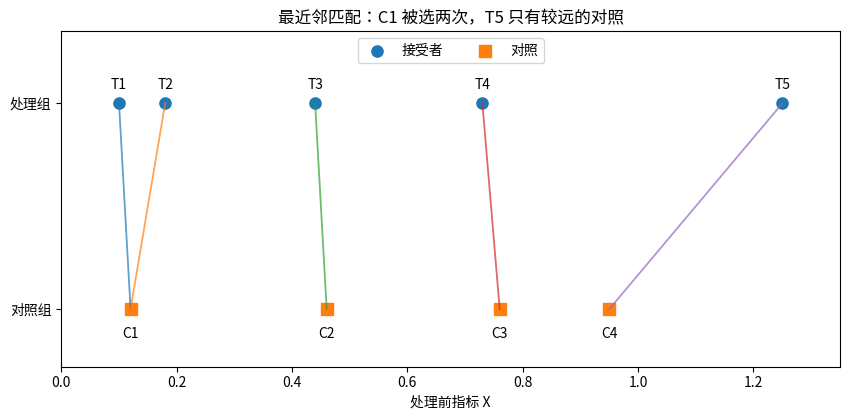

In [2]:
toy = pd.DataFrame({
    "id": ["T1", "T2", "T3", "T4", "T5", "C1", "C2", "C3", "C4"],
    "T": [1, 1, 1, 1, 1, 0, 0, 0, 0],
    "X": [0.10, 0.18, 0.44, 0.73, 1.25, 0.12, 0.46, 0.76, 0.95],
    "Y": [12., 13., 17., 20., 26., 10., 14., 17., 19.],
})
toy_t = np.flatnonzero(toy["T"].to_numpy() == 1)
toy_c = np.flatnonzero(toy["T"].to_numpy() == 0)
toy_x, toy_y = toy["X"].to_numpy(), toy["Y"].to_numpy()

# 逐个接受者算距离。Y 不参与挑选对照。
manual_rows = []
for i in toy_t:
    distances = np.abs(toy_x[toy_c] - toy_x[i])
    j = toy_c[np.argmin(distances)]
    manual_rows.append({"treated": i, "control": j, "distance": abs(toy_x[i]-toy_x[j])})
manual_pairs = pd.DataFrame(manual_rows)
pair_view = pd.DataFrame({
    "接受者": toy.loc[manual_pairs["treated"], "id"].to_numpy(),
    "X_接受者": toy_x[manual_pairs["treated"]],
    "对照": toy.loc[manual_pairs["control"], "id"].to_numpy(),
    "X_对照": toy_x[manual_pairs["control"]],
    "距离": manual_pairs["distance"],
    "结局差": toy_y[manual_pairs["treated"]]-toy_y[manual_pairs["control"]],
})
display(pair_view.round(3))
print(f"5 位接受者的匹配差值均值：{pair_view['结局差'].mean():.3f}")

fig, ax = plt.subplots(figsize=(8.6, 4.3))
for row in manual_pairs.itertuples():
    ax.plot([toy_x[row.treated], toy_x[row.control]], [1, 0], linewidth=1.3, alpha=0.7)
ax.scatter(toy_x[toy_t], np.ones(len(toy_t)), marker="o", s=65, label="接受者")
ax.scatter(toy_x[toy_c], np.zeros(len(toy_c)), marker="s", s=65, label="对照")
for i in range(len(toy)):
    height = 1.07 if toy.loc[i, "T"] == 1 else -0.14
    ax.text(toy_x[i], height, toy.loc[i, "id"], ha="center", fontsize=10)
ax.set(xlabel="处理前指标 X", title="最近邻匹配：C1 被选两次，T5 只有较远的对照",
       ylim=(-0.28, 1.35), xlim=(0, 1.35))
ax.set_yticks([0, 1], ["对照组", "处理组"])
ax.legend(loc="upper center", ncol=2)
fig.tight_layout()
plt.show()

T1 和 T2 都选了 C1；T5 选到 C4，但距离为 0.30，明显大于其他配对。“每个人都有最近邻”和“每个人都有合适对照”是两回事。

### 2. 加上距离限制，并记录没配上的人

距离超过上限就不接受这次匹配，这个上限称为卡钳（caliper）。本例先用 0.10。T5 会被留下未匹配记录，而不是把他的结局差填成 0，也不是继续除以原来的 5。

原书第 15.2 节讨论了丢弃难以匹配的接受者会改变研究人群。下面把这一点落实为两张表：`pairs` 保存真正的配对，`audit` 为每位原始接受者保存是否匹配、候选数量和原因。阈值和记录格式是本篇的实现补充。

In [3]:
def nearest_match(features, treatment, ratio: int = 1, replace: bool = True,
                  caliper=None, order=None):
    """固定 1:M 最近邻匹配；输入仅含设计信息，索引均为原数组的位置。

    每位接受者必须找到 M 个不同对照才保留；不同接受者之间可按 replace 复用。
    无放回时是按 order 顺序进行的贪心匹配，不是全局最优匹配。
    距离相同按对照的原始行位置选取；无匹配时返回空 pairs，不虚构配对。
    """
    F, z = np.asarray(features, dtype=float), np.asarray(treatment)
    if F.ndim == 1:
        F = F[:, None]
    if F.ndim != 2 or F.shape[1] == 0 or z.ndim != 1 or len(F) != len(z):
        raise ValueError("features 应为一维或二维，treatment 应为等长的一维向量。")
    if not np.isfinite(F).all() or not np.isin(z, [0, 1]).all():
        raise ValueError("特征必须有限，处理只能为 0/1。")
    treated, controls = np.flatnonzero(z == 1), np.flatnonzero(z == 0)
    if min(len(treated), len(controls)) == 0:
        raise ValueError("处理组与对照组都必须存在。")
    if isinstance(ratio, bool) or not isinstance(ratio, (int, np.integer)) or ratio < 1:
        raise ValueError("ratio 必须是正整数。")
    if not isinstance(replace, (bool, np.bool_)):
        raise ValueError("replace 必须为布尔值。")
    limit = np.inf if caliper is None else float(caliper)
    if np.isnan(limit) or limit < 0:
        raise ValueError("caliper 必须非负，None 表示不限制。")
    sequence = treated if order is None else np.asarray(order)
    if (sequence.ndim != 1 or not np.issubdtype(sequence.dtype, np.integer)
            or not np.array_equal(np.sort(sequence), treated)):
        raise ValueError("order 必须是所有接受者原始行位置的一个排列。")

    used = np.zeros(len(z), dtype=bool)
    links, audit_rows = [], []
    for i in sequence:
        candidates = controls if replace else controls[~used[controls]]
        distances = np.linalg.norm(F[candidates] - F[i], axis=1)
        closest = float(distances.min()) if len(distances) else np.inf
        ok = distances <= limit
        available, distance_ok = candidates[ok], distances[ok]
        enough = len(available) >= ratio
        audit_rows.append({
            "treated": int(i), "matched": enough, "eligible": len(available),
            "closest_available": closest,
            "reason": "已匹配" if enough else ("无可用对照" if not len(candidates) else "阈值内对照不足"),
        })
        if not enough:
            continue
        # 稳定排序保留原行位置的并列处理规则；1:1 时直接取最小值。
        chosen = np.array([np.argmin(distance_ok)]) if ratio == 1 else np.argsort(distance_ok, kind="stable")[:ratio]
        for rank, k in enumerate(chosen, start=1):
            links.append((int(i), int(available[k]), rank, float(distance_ok[k])))
        if not replace:
            used[available[chosen]] = True

    pairs = pd.DataFrame(links, columns=["treated", "control", "rank", "distance"])
    pairs = pairs.astype({"treated": int, "control": int, "rank": int, "distance": float})
    audit = pd.DataFrame(audit_rows).sort_values("treated").reset_index(drop=True)
    return pairs, audit


toy_pairs, toy_audit = nearest_match(toy_x, toy["T"], caliper=0.10)
display(toy_audit.assign(id=toy.loc[toy_audit["treated"], "id"].to_numpy())
        [["id", "matched", "eligible", "closest_available", "reason"]].round(3))
print("真正保留的配对：")
display(toy_pairs)
assert toy_audit["matched"].sum() == 4
assert len(toy_pairs) == 4 and toy_pairs["distance"].max() <= 0.10

,id,matched,eligible,closest_available,reason
0,T1,True,1,0.02,已匹配
1,T2,True,1,0.06,已匹配
2,T3,True,1,0.02,已匹配
3,T4,True,1,0.03,已匹配
4,T5,False,0,0.30,阈值内对照不足


真正保留的配对：


,treated,control,rank,distance
0,0,5,1,0.02
1,1,5,1,0.06
2,2,6,1,0.02
3,3,7,1,0.03


### 3. 重复出现的对照，要按使用次数计入

设保留的接受者集合为 $\mathcal S_T$，人数为 $q$，每位保留者都有 $M$ 个对照。令 $K_j$ 表示对照 $j$ 被不同接受者选中的次数，则：

$$
\widehat\tau_{\mathcal S_T}
=\frac1q\sum_{i\in\mathcal S_T}Y_i
-\frac1q\sum_{j:T_j=0}\frac{K_j}{M}Y_j,
\qquad
\sum_{j:T_j=0}\frac{K_j}{M}=q.
$$

所以，匹配也产生了权重：接受者各为 1，对照为 $K_j/M$。这是对原书匹配平均式重新整理得到的有限样本恒等式，使用次数的作用也出现在第 15.4 节的线性展开中。不能把重复对照去重后再等权平均，否则就换了一种估计。

若所有接受者都保留，$q=n_1$；若卡钳删去了一部分接受者，结果对应保留者的比较，不能直接称为原始全体接受者的 ATT。这个变化与上一份修剪人群的道理相同。

In [4]:
def matching_weights(pairs, n: int):
    """把配对长表整理为原始个体上的权重，每位保留接受者总权重为 1。"""
    if pairs.empty:
        raise ValueError("没有成功配对，无法计算匹配估计。")
    a = pairs["treated"].to_numpy(dtype=int)
    b = pairs["control"].to_numpy(dtype=int)
    if min(a.min(), b.min()) < 0 or max(a.max(), b.max()) >= n:
        raise ValueError("配对索引超出原始样本范围。")
    if np.intersect1d(a, b).size or pairs.duplicated(["treated", "control"]).any():
        raise ValueError("处理与对照索引应不交叉，且同一接受者不能重复选择同一个对照。")
    ids, number = np.unique(a, return_counts=True)
    if np.unique(number).size != 1:
        raise ValueError("本篇函数只处理固定 1:M 配对。")
    M = int(number[0])
    w1, w0 = np.zeros(n), np.zeros(n)
    w1[ids] = 1.0
    np.add.at(w0, b, 1.0/M)
    np.testing.assert_allclose(w1.sum(), w0.sum(), atol=1e-10)
    return w1, w0


def matched_att(outcome, pairs):
    y = np.asarray(outcome, dtype=float)
    if y.ndim != 1 or not np.isfinite(y).all():
        raise ValueError("结局必须是一维有限数值。")
    w1, w0 = matching_weights(pairs, len(y))
    return float((np.dot(w1, y)-np.dot(w0, y))/w1.sum())


def effective_sample_size(weights):
    w = np.asarray(weights, dtype=float)
    if w.ndim != 1 or not np.isfinite(w).all() or (w < 0).any() or w.sum() <= 0:
        raise ValueError("权重必须是一维有限非负数，且权重和为正。")
    return float(w.sum()**2/np.dot(w, w))


toy_w1, toy_w0 = matching_weights(toy_pairs, len(toy))
selected_t = np.flatnonzero(toy_w1)
selected_c = np.flatnonzero(toy_w0)
correct = matched_att(toy_y, toy_pairs)
# 故意计算“去重后等权”的结果，作为不同算法的对照。
deduplicated = toy_y[selected_t].mean()-toy_y[selected_c].mean()
display(toy.assign(匹配权重=toy_w1+toy_w0)[["id", "T", "Y", "匹配权重"]])
display(pd.Series({"逐对平均 / 使用次数加权": correct,
                   "去重后把对照等权平均（不同算法）": deduplicated,
                   "保留接受者人数": toy_w1.sum(),
                   "实际使用的不同对照人数": len(selected_c),
                   "对照ESS": effective_sample_size(toy_w0)}, name="结果").to_frame().round(4))
np.testing.assert_allclose(correct, (toy_y[toy_pairs.treated]-toy_y[toy_pairs.control]).mean())

,id,T,Y,匹配权重
0,T1,1,12.0,1.0
1,T2,1,13.0,1.0
2,T3,1,17.0,1.0
3,T4,1,20.0,1.0
4,T5,1,26.0,0.0
5,C1,0,10.0,2.0
6,C2,0,14.0,1.0
7,C3,0,17.0,1.0
8,C4,0,19.0,0.0


,结果
逐对平均 / 使用次数加权,2.7500
去重后把对照等权平均（不同算法）,1.8333
保留接受者人数,4.0000
实际使用的不同对照人数,3.0000
对照ESS,2.6667


加上卡钳后，4 位接受者的匹配平均差为 2.75。把 3 位不同对照去重后等权平均，则得到约 1.83。不是结局变了，而是 C1 从两份贡献变成一份，比较人群的组成也随之改变。

## 完整案例二：在观察性数据中匹配

### 1. 数据不变，估计目标换成接受者

沿用第五、六篇的生成规则。$X_1,X_2$ 独立服从 $\operatorname{Uniform}(-1,1)$，$X_3\sim\operatorname{Bernoulli}(0.5)$。处理概率和潜在结局为：

$$
\begin{aligned}
\eta(X)&=-0.4+X_1-0.5X_2+0.6X_3+1.8(X_1^2-1/3)+1.2X_1X_2,\\
e(X)&=\operatorname{expit}\{\eta(X)\},\qquad T\mid X\sim\operatorname{Bernoulli}\{e(X)\},\\
\mu_0(X)&=10+2X_1+1.5X_2+2X_3+6X_1^2+3X_1X_2,\\
\tau(X)&=2+0.5X_1+0.8X_3,\\
Y(0)&=\mu_0(X)+\varepsilon,\quad Y(1)=Y(0)+\tau(X),\quad \varepsilon\sim N(0,1).
\end{aligned}
$$

所有外生随机项相互独立。全体 ATE 还是 2.4，但接受者的 $X$ 分布不同，所以不能再用 2.4 检验一个 ATT 估计是否准确。先只把 $X,T$ 交给匹配程序，结局和真值单独保存。

In [5]:
def expit(value):
    return np.exp(-np.logaddexp(0.0, -np.asarray(value, dtype=float)))


def make_observational_data(n: int, seed: int):
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError("n 必须是至少为 20 的整数。")
    rng = np.random.default_rng(seed)
    x1, x2 = rng.uniform(-1, 1, n), rng.uniform(-1, 1, n)
    x3 = rng.binomial(1, 0.5, n)
    eta = -0.4+x1-0.5*x2+0.6*x3+1.8*(x1**2-1/3)+1.2*x1*x2
    p = expit(eta)
    t = rng.binomial(1, p)
    mu0 = 10+2*x1+1.5*x2+2*x3+6*x1**2+3*x1*x2
    tau = 2+0.5*x1+0.8*x3
    y0 = mu0+rng.normal(0, 1, n)
    y1 = y0+tau
    design = pd.DataFrame({"X1": x1, "X2": x2, "X3": x3, "T": t})
    return design, np.where(t == 1, y1, y0), {
        "propensity": p, "mu0": mu0, "y0": y0, "y1": y1,
        "tau": tau, "population_ate": 2.4,
    }


design, outcome, truth = make_observational_data(N_MAIN, SEED_DATA)
t = design["T"].to_numpy()
display(design.head(8).round(4))
display(design.groupby("T").agg(n=("T", "size"), X1均值=("X1", "mean"),
                               X2均值=("X2", "mean"), X3比例=("X3", "mean")).round(4))

,X1,X2,X3,T
0,0.5479,0.6584,0,0
1,-0.1222,0.1882,0,0
2,0.7172,-0.5103,1,1
3,0.3947,0.4914,0,0
4,-0.8116,-0.8310,0,1
5,0.9512,0.5488,0,1
6,0.5223,0.1800,1,1
7,0.5721,-0.7785,1,1


,n,X1均值,X2均值,X3比例
T,,,,
0,1565,-0.1398,0.0456,0.4441
1,1435,0.1505,-0.0917,0.5756


### 2. 距离要在哪个尺度上计算？

原书先介绍协变量的欧氏距离和 Mahalanobis 距离，再讨论评分或评分 logit 上的一维匹配。[1，第 15.2 节]

本篇实现两类坐标。第一类是把 $X_1,X_2,X_3$ 按全样本标准差缩放，再取欧氏距离，避免某列仅因单位较大就支配配对。第二类是 Logistic 模型的线性预测值：

$$
\widehat\eta_i=\operatorname{logit}(\widehat e_i)
=\log\frac{\widehat e_i}{1-\widehat e_i},\qquad
 d_{ij}=|\widehat\eta_i-\widehat\eta_j|.
$$

Logistic 回归下可直接用设计矩阵乘系数得到 $\widehat\eta$，不必先把概率取对数。本篇仍比较“仅主效应”和“含二次与交互”两个事先给定的评分模型。它们都只用 $X,T$ 拟合。[3]

原书用平方形式写欧氏距离；这里返回平方根形式。取最近者的排序不变，但距离数值和卡钳单位要按本篇定义解释。评分与 logit 的最近邻也不必相同：单调变换保留排序，却不保留相邻点的距离比例。

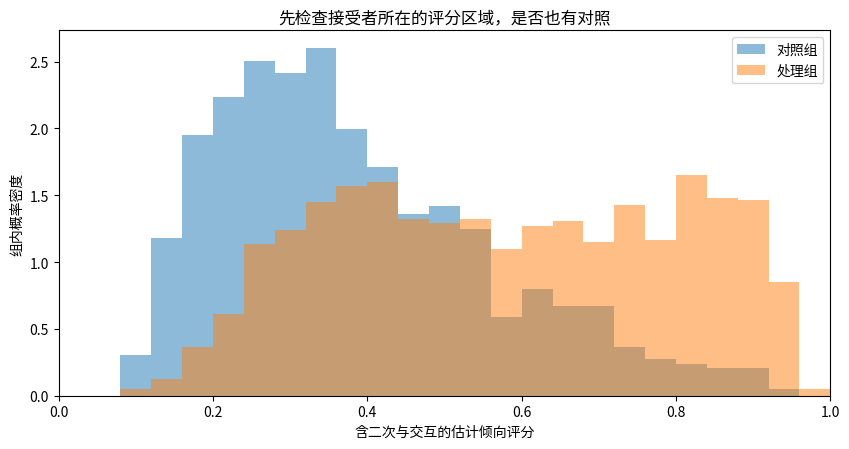

In [6]:
def covariate_matrix(data, specification="rich", intercept=True):
    x1, x2, x3 = (data[name].to_numpy(dtype=float) for name in ("X1", "X2", "X3"))
    columns = [x1, x2, x3]
    if specification == "rich":
        columns += [x1**2, x1*x2]
    elif specification != "main":
        raise ValueError("specification 只能是 main 或 rich。")
    if intercept:
        columns = [np.ones(len(data))]+columns
    return np.column_stack(columns)


def fit_logistic(matrix, treatment):
    """无惩罚二项 GLM；收敛与分离问题不以静默截断掩盖。"""
    A, z = np.asarray(matrix, dtype=float), np.asarray(treatment, dtype=float)
    if A.ndim != 2 or z.ndim != 1 or len(A) != len(z):
        raise ValueError("设计矩阵应为二维，处理应为等长的一维向量。")
    if not np.isfinite(A).all() or not np.isfinite(z).all():
        raise ValueError("输入不能包含非有限值。")
    if not np.isin(z, [0, 1]).all() or np.unique(z).size != 2:
        raise ValueError("处理必须为 0/1，并且两组都存在。")
    if np.linalg.matrix_rank(A) < A.shape[1]:
        raise ValueError("设计矩阵列不满秩。")
    with warnings.catch_warnings():
        warnings.simplefilter("error", PerfectSeparationWarning)
        result = sm.GLM(z, A, family=sm.families.Binomial()).fit(maxiter=100, tol=1e-10)
    if not result.converged or not np.isfinite(result.params).all():
        raise RuntimeError("Logistic 模型未正常收敛。")
    return result


fits, logits, scores = {}, {}, {}
for specification in ("main", "rich"):
    A = covariate_matrix(design, specification)
    fits[specification] = fit_logistic(A, t)
    logits[specification] = A @ fits[specification].params
    scores[specification] = expit(logits[specification])

X_raw = design[["X1", "X2", "X3"]].to_numpy()
x_scale = X_raw.std(axis=0, ddof=1)
if np.any(x_scale == 0):
    raise ValueError("出现常数特征，请先检查数据与距离定义。")
X_scaled = (X_raw-X_raw.mean(axis=0))/x_scale

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for group, label in [(0, "对照组"), (1, "处理组")]:
    ax.hist(scores["rich"][t == group], bins=np.linspace(0, 1, 26),
            density=True, alpha=0.5, label=label)
ax.set(xlabel="含二次与交互的估计倾向评分", ylabel="组内概率密度",
       title="先检查接受者所在的评分区域，是否也有对照", xlim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

### 3. 匹配规则先定下来

主案例使用一对一、有放回匹配。比较标准化协变量、两种 logit 评分，并对较完整的评分模型另设卡钳：$0.10\times\operatorname{SD}(\widehat\eta)$，标准差在原始全样本中计算。这个数只用于展示距离限制，后面会把多个阈值的结果全部列出，不根据结局挑一个“最好”的阈值。

有放回是指同一个对照能服务于不同接受者，不是在同一位接受者的一对多配对中重复取同一个人。没有放回时，先选走的对照不能再次使用；本篇函数按指定顺序贪心选取，这与原书讨论的全局组合优化并不相同，最后的练习会具体比较。[1，第 15.2 节]

In [7]:
def design_summary(pairs, audit, treatment):
    z = np.asarray(treatment)
    n1, n0 = int((z == 1).sum()), int((z == 0).sum())
    q = int(audit["matched"].sum())
    if pairs.empty:
        return {"原始接受者": n1, "保留接受者": 0, "未匹配接受者": n1,
                "不同对照": 0, "未用对照": n0, "配对条数": 0,
                "最大复用次数": 0, "对照ESS": np.nan}
    _, w0 = matching_weights(pairs, len(z))
    reuse = pairs["control"].value_counts()
    return {"原始接受者": n1, "保留接受者": q, "未匹配接受者": n1-q,
            "不同对照": len(reuse), "未用对照": n0-len(reuse), "配对条数": len(pairs),
            "最大复用次数": int(reuse.max()), "对照ESS": effective_sample_size(w0)}


main_limit = CALIPER_SD*logits["rich"].std(ddof=1)
settings = {
    "标准化X": (X_scaled, None),
    "主效应评分": (logits["main"], None),
    "完整评分": (logits["rich"], None),
    "完整评分+卡钳": (logits["rich"], main_limit),
}
matched, audits = {}, {}
for name, (F, limit) in settings.items():
    matched[name], audits[name] = nearest_match(F, t, ratio=1, replace=True, caliper=limit)

print(f"卡钳的实际 logit 距离上限：{main_limit:.4f}")
display(pd.DataFrame({name: design_summary(matched[name], audits[name], t)
                      for name in settings}).T.round(2))
print("完整评分匹配：前 8 条配对（均为原始数组的位置）")
display(matched["完整评分"].head(8).round(5))

卡钳的实际 logit 距离上限：0.1070


,原始接受者,保留接受者,未匹配接受者,不同对照,未用对照,配对条数,最大复用次数,对照ESS
标准化X,1435.0,1435.0,0.0,694.0,871.0,1435.0,18.0,344.64
主效应评分,1435.0,1435.0,0.0,740.0,825.0,1435.0,16.0,422.93
完整评分,1435.0,1435.0,0.0,660.0,905.0,1435.0,29.0,309.80
完整评分+卡钳,1435.0,1418.0,17.0,660.0,905.0,1418.0,17.0,333.45


完整评分匹配：前 8 条配对（均为原始数组的位置）


,treated,control,rank,distance
0,2,654,1,0.00135
1,4,1083,1,0.00009
2,5,419,1,0.02400
3,6,1708,1,0.00184
4,7,1555,1,0.00550
5,8,1550,1,0.00681
6,11,1026,1,0.00265
7,12,923,1,0.00118


### 4. 分数配近了，原始变量也平衡了吗？

评分是用来选人的，最后仍要检查处理前变量。对有放回匹配，接受者按 1 加权，对照按 $K_j/M$ 加权。若去重后等权检查平衡，检查的就不是实际估计使用的比较。[1，第 11.3、15.5.3 节]

这里沿用第五、六篇的标准化均值差（SMD）：分母始终固定为匹配前两组方差均值的平方根，匹配前后不重新换尺子。该定义是本系列的诊断约定；原书第 15.5.3 节展示的是回归检验，本篇改用 SMD，并补充二次项和交互项：

$$
\operatorname{SMD}(h)=
\frac{\overline h_{1,w}-\overline h_{0,w}}
{\sqrt{(s^2_{h,1,\mathrm{before}}+s^2_{h,0,\mathrm{before}})/2}}.
$$

图中的 0.1 只是一条阅读辅助线，不是可忽略性已成立的检验标准。小均值差也不等于整个分布相同，更不能证明未测混杂已经消失。

,匹配前,标准化X,主效应评分,完整评分,完整评分+卡钳
X1,0.5136,0.0047,0.0872,-0.0477,-0.0476
X2,-0.2415,0.0021,0.0941,0.0392,0.0289
X3,0.2653,0.0000,-0.0661,-0.0070,-0.0071
X1²,0.5846,0.0335,0.6265,0.0416,0.0446
X1×X2,0.2766,0.0052,0.3700,0.0508,0.0339


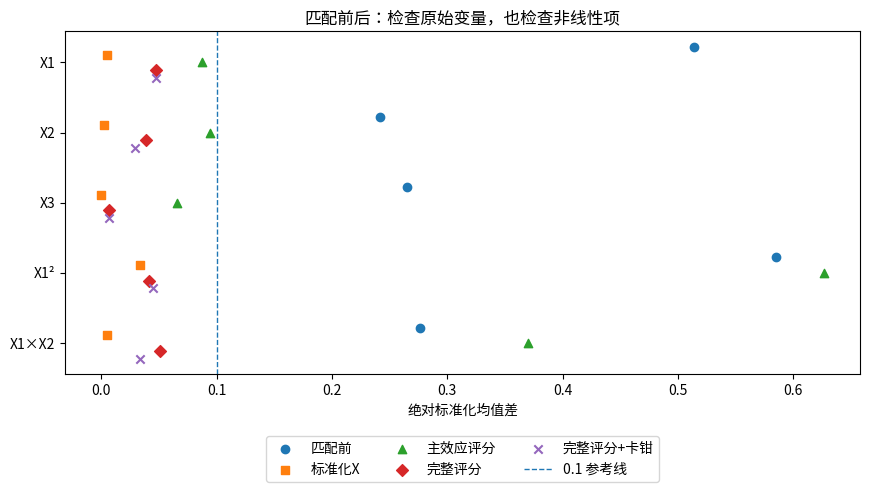

In [8]:
feature_names = ["X1", "X2", "X3", "X1²", "X1×X2"]
H = covariate_matrix(design, "rich", intercept=False)
smd_scale = np.sqrt((H[t == 1].var(axis=0, ddof=1)+H[t == 0].var(axis=0, ddof=1))/2)


def standardized_difference(features, w1, w0, scale):
    F = np.asarray(features, dtype=float)
    s = np.asarray(scale, dtype=float)
    if F.ndim != 2 or s.shape != (F.shape[1],) or not np.isfinite(F).all() or not np.isfinite(s).all() or (s <= 0).any():
        raise ValueError("特征应为二维有限数值，SMD 分母应为等长的正数向量。")
    for w in (w1, w0):
        w = np.asarray(w, dtype=float)
        if w.shape != (len(F),) or not np.isfinite(w).all() or (w < 0).any() or w.sum() <= 0:
            raise ValueError("两组权重必须有限非负、与特征等长，且权重和为正。")
    return (np.average(F, axis=0, weights=w1)-np.average(F, axis=0, weights=w0))/s


balance = {"匹配前": standardized_difference(H, t, 1-t, smd_scale)}
for name, pairs in matched.items():
    w1, w0 = matching_weights(pairs, len(t))
    balance[name] = standardized_difference(H, w1, w0, smd_scale)
balance = pd.DataFrame(balance, index=feature_names)
display(balance.round(4))

fig, ax = plt.subplots(figsize=(8.8, 5.1))
for offset, (name, marker) in zip(np.linspace(-0.22, 0.22, len(balance.columns)),
                                 zip(balance.columns, ["o", "s", "^", "D", "x"])):
    ax.scatter(balance[name].abs(), np.arange(len(feature_names))+offset, marker=marker, label=name)
ax.axvline(0.1, linestyle="--", linewidth=1, label="0.1 参考线")
ax.set_yticks(np.arange(len(feature_names)), feature_names)
ax.set(xlabel="绝对标准化均值差", title="匹配前后：检查原始变量，也检查非线性项")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
fig.tight_layout()
plt.show()

只用主效应的评分虽然把原始三列的均值差压小了，但 $X_1^2$ 的绝对 SMD 仍有 0.626，甚至高于匹配前的 0.585。它没有把决定处理分配的非线性关系处理好。完整评分下，这五项绝对 SMD 都小于 0.051；这说明本次观察变量的均值更接近，不是因果假设得到了证明。

### 5. 查距离，也查对照被用了几次

同样是 1,000 对，可能用了接近 1,000 位不同对照，也可能主要依赖其中很少一部分。下面把距离分位数、不同对照人数与使用次数分开看。协变量距离和 logit 距离单位不同，不把它们放在一起排名。

有放回减少了对照之间的竞争，却可能让某个对照被反复使用。原书指出这种复用会引入依赖；下面的 ESS 仅概括权重集中程度，不是匹配估计方差的完整公式。[1，第 15.2 节]

,主效应评分,完整评分,完整评分+卡钳
中位距离,0.00064,0.00115,0.00112
90%距离,0.00391,0.01165,0.01085
99%距离,0.01817,0.14143,0.05115
最大距离,0.14146,0.24774,0.10076


完整评分匹配用了 660 位不同对照，最大复用 29 次。
未使用的原始对照：905 位。


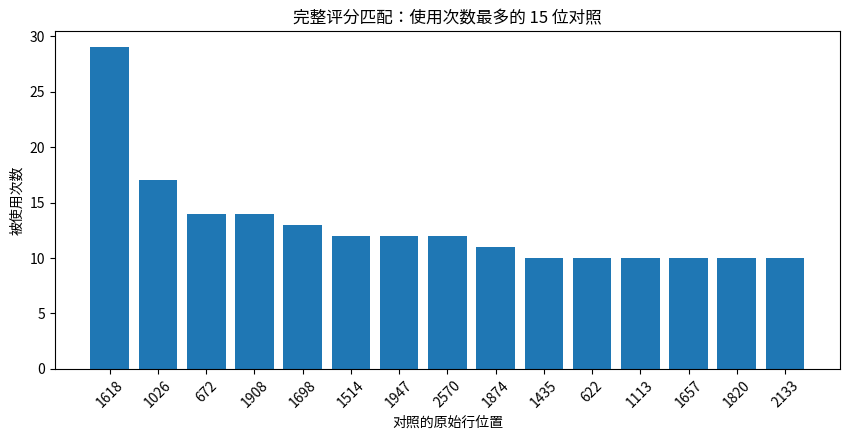

In [9]:
score_distance = pd.DataFrame({name: pairs["distance"].quantile([0.5, 0.9, 0.99, 1])
                               for name, pairs in matched.items() if name != "标准化X"})
score_distance.index = ["中位距离", "90%距离", "99%距离", "最大距离"]
display(score_distance.round(5))
reuse = matched["完整评分"]["control"].value_counts().sort_values(ascending=False)
print(f"完整评分匹配用了 {len(reuse)} 位不同对照，最大复用 {reuse.max()} 次。")
print(f"未使用的原始对照：{int((t == 0).sum())-len(reuse)} 位。")

fig, ax = plt.subplots(figsize=(8.6, 4.5))
top_reuse = reuse.iloc[:15]
ax.bar(np.arange(len(top_reuse)), top_reuse.to_numpy())
ax.set_xticks(np.arange(len(top_reuse)), top_reuse.index.astype(str), rotation=45)
ax.set(xlabel="对照的原始行位置", ylabel="被使用次数",
       title="完整评分匹配：使用次数最多的 15 位对照")
fig.tight_layout()
plt.show()

### 6. 现在才代入结局

先给出两个不同的真值参照。一个是这份样本中原始接受者的平均真实效应；另一个是生成总体中的 ATT，后面的重复模拟使用它。

在本例中，个体效应就是 $\tau(X)$。由条件期望可得：

$$
\tau_T=\frac{E[e(X)\tau(X)]}{E[e(X)]}.
$$

这是把 ATT 定义应用到本例生成机制后的计算。代码用数值积分求总体值，不把生成机制的评分或效应函数提供给匹配算法。对卡钳后留下的接受者，另外列出其平均真实效应，不能拿原始接受者的真值与之混比较。

In [10]:
def population_att_reference(nodes: int = 64):
    """仅作模拟评价：Gauss–Legendre 积分计算已知生成总体的 ATT。"""
    u, w = np.polynomial.legendre.leggauss(nodes)
    a, b = np.meshgrid(u, u, indexing="ij")
    weights = np.outer(w, w)/4  # 两个 Uniform(-1,1) 密度相乘
    numerator, denominator = 0.0, 0.0
    for x3 in (0, 1):
        eta = -0.4+a-0.5*b+0.6*x3+1.8*(a*a-1/3)+1.2*a*b
        e = expit(eta)
        numerator += 0.5*np.sum(weights*e*(2+0.5*a+0.8*x3))
        denominator += 0.5*np.sum(weights*e)
    return float(numerator/denominator)


population_att = population_att_reference()
sample_att = float(truth["tau"][t == 1].mean())
print(f"总体 ATE：{truth['population_ate']:.6f}")
print(f"总体 ATT（数值积分）：{population_att:.6f}")
print(f"本次原始接受者的真实平均效应：{sample_att:.6f}")
np.testing.assert_allclose(population_att, population_att_reference(96), atol=1e-11)

rows = [{"方法": "原始均值差", "保留接受者": int(t.sum()),
         "估计": outcome[t == 1].mean()-outcome[t == 0].mean(), "对应接受者真值": sample_att}]
for name, pairs in matched.items():
    ids = np.unique(pairs["treated"])
    rows.append({"方法": name, "保留接受者": len(ids), "估计": matched_att(outcome, pairs),
                 "对应接受者真值": truth["tau"][ids].mean()})
effect_table = pd.DataFrame(rows).set_index("方法")
effect_table["估计减对应真值"] = effect_table["估计"]-effect_table["对应接受者真值"]
display(effect_table.round(4))

总体 ATE：2.400000
总体 ATT（数值积分）：2.526437
本次原始接受者的真实平均效应：2.535718


,保留接受者,估计,对应接受者真值,估计减对应真值
方法,,,,
原始均值差,1435,4.4944,2.5357,1.9587
标准化X,1435,2.6974,2.5357,0.1617
主效应评分,1435,4.2039,2.5357,1.6681
完整评分,1435,2.6670,2.5357,0.1312
完整评分+卡钳,1418,2.6251,2.5268,0.0982


原始均值差约为 4.494，主效应评分匹配后仍有 4.204，离本次接受者真值 2.536 很远。完整评分给出约 2.667，标准化 $X$ 给出约 2.697。前面诊断表里遗漏的非线性不平衡，在结局比较中留下了明显影响。

单次估计与真值之差既可能来自匹配残差，也可能只是结局噪声。即使两位接受者都匹配到同一个对照，他们的比较也不是两份完全独立的信息。后面会分别把这些因素拆开。

### 7. 配得不完全相同，怎样做偏差校正？

若接受者和对照的 $X$ 不完全相同，两个人即使都不接受处理，平均结局也可能不同。以一对一为例，原来的差值 $Y_i-Y_j$ 中会混入 $\mu_0(X_i)-\mu_0(X_j)$。

原书用结果回归估计这一差异，再从匹配结果中减去：

$$
\widehat B_T=\frac1q\sum_{i\in\mathcal S_T}\frac1M
\sum_{j\in\mathcal J_i}\{\widehat\mu_0(X_i)-\widehat\mu_0(X_j)\},
\qquad
\widehat\tau_T^{\mathrm{bc}}=\widehat\tau_T^{\mathrm{match}}-\widehat B_T.
$$

$q=n_1$ 时就是第 15.4 节的 ATT 偏差校正式。这里先固定“标准化 $X$”的配对，用原始对照拟合结果模型，再预测所有人的未处理均值；不因结果模型的拟合结果重新挑配对。[1，第 15.4 节]

下面故意分别拟合仅主效应和含二次、交互的结果模型。校正项也依赖模型，不能保证任意模型都能把剩余差异校正好。

In [11]:
def control_mean_predictions(data, outcome, specification="rich"):
    A = covariate_matrix(data, specification)
    z = data["T"].to_numpy()
    y = np.asarray(outcome, dtype=float)
    if y.shape != (len(data),) or not np.isfinite(y).all():
        raise ValueError("结局应为与 data 等长的一维有限数组。")
    beta, _, rank, _ = np.linalg.lstsq(A[z == 0], y[z == 0], rcond=None)
    if rank < A.shape[1]:
        raise ValueError("对照结果模型不满秩。")
    return A @ beta


def bias_corrected_att(outcome, pairs, mu0_hat):
    y, mu = np.asarray(outcome, dtype=float), np.asarray(mu0_hat, dtype=float)
    if y.ndim != 1 or mu.shape != y.shape or not np.isfinite(mu).all():
        raise ValueError("mu0_hat 应为与结局等长的一维有限数组。")
    raw = matched_att(y, pairs)
    a, b = pairs["treated"].to_numpy(), pairs["control"].to_numpy()
    correction = float(np.mean(mu[a]-mu[b]))  # 每位接受者均有同样的 M
    return raw-correction, correction


base_pairs = matched["标准化X"]
correction_rows = []
for specification in ("main", "rich"):
    mu0_hat = control_mean_predictions(design, outcome, specification)
    corrected, adjustment = bias_corrected_att(outcome, base_pairs, mu0_hat)
    correction_rows.append({"结果模型": specification, "原始匹配": matched_att(outcome, base_pairs),
                            "减去的校正项": adjustment, "校正后": corrected})
    # 原书命题 15.3 的残差形式，用原始个体的复用权重核对。
    wt, wc = matching_weights(base_pairs, len(t))
    residual_form = np.dot(wt-wc, outcome-mu0_hat)/wt.sum()
    np.testing.assert_allclose(corrected, residual_form, atol=1e-11)
display(pd.DataFrame(correction_rows).set_index("结果模型").round(5))
print(f"两种结果模型使用完全相同的 {len(base_pairs)} 对。")
print(f"原始接受者的真实平均效应：{sample_att:.5f}")

,原始匹配,减去的校正项,校正后
结果模型,,,
main,2.6974,0.00392,2.69348
rich,2.6974,0.07061,2.62680


两种结果模型使用完全相同的 1435 对。
原始接受者的真实平均效应：2.53572


完整结果模型减去的校正项约为 0.071，只有主效应时约为 0.004。两者使用的配对没有变，只是对“未处理基线差异”的估计不同。

再用模拟中才知道的 $\mu_0$，检查刚才的解释是否成立。本例每人的两种潜在结局共享同一个噪声，所以逐对可以精确写成：

$$
Y_i-Y_j=\tau(X_i)+\{\mu_0(X_i)-\mu_0(X_j)\}+(\varepsilon_i-\varepsilon_j).
$$

分别求平均，就把估计分成接受者真值、基线不匹配和噪声差三部分。这是本例的代数核对，不是在真实研究中能直接完成的误差分解。

In [12]:
a = base_pairs["treated"].to_numpy()
b = base_pairs["control"].to_numpy()
noise = truth["y0"]-truth["mu0"]
parts = pd.Series({
    "接受者真实平均效应": truth["tau"][a].mean(),
    "未处理基线不匹配": (truth["mu0"][a]-truth["mu0"][b]).mean(),
    "结局噪声差": (noise[a]-noise[b]).mean(),
})
display(parts.to_frame("分解").round(6))
print(f"三部分合计：{parts.sum():.6f}")
print(f"直接计算匹配估计：{matched_att(outcome, base_pairs):.6f}")
np.testing.assert_allclose(parts.sum(), matched_att(outcome, base_pairs), atol=1e-11)
oracle_bc, _ = bias_corrected_att(outcome, base_pairs, truth["mu0"])
np.testing.assert_allclose(oracle_bc, sample_att+parts["结局噪声差"], atol=1e-11)
print("已知基线函数的校正能去掉基线不匹配，但不会消除本次噪声差。")

,分解
接受者真实平均效应,2.535718
未处理基线不匹配,0.070220
结局噪声差,0.091463


三部分合计：2.697401
直接计算匹配估计：2.697401
已知基线函数的校正能去掉基线不匹配，但不会消除本次噪声差。


## 进一步分析：找不到好对照时，谁被留下？

### 1. 另设一个重叠较差的例子

这次只用一维 $X$，使目标变化容易读出来：

$$
\begin{aligned}
X&\sim\operatorname{Uniform}(0,1),& e(X)&=\operatorname{expit}(-3+7X),\\
T\mid X&\sim\operatorname{Bernoulli}\{e(X)\},& \mu_0(X)&=10+5X+4X^2,\\
Y(0)&=\mu_0(X)+\varepsilon,& Y(1)&=Y(0)+1+3X,\quad\varepsilon\sim N(0,1).
\end{aligned}
$$

$X$ 越大，越可能接受处理，效应也越大。这不是原书的实证案例，而是用来实现第 15.2 节“难匹配者被排除后人群改变”的教学构造。

仍然先从 $X,T$ 估计 logit 评分，然后考察事先列好的距离上限。这里的 0.20、0.08、0.03、0.01 都是 logit 的绝对距离，不是概率差，也不是标准差倍数。实际分析中必须像这样写明尺度。

In [13]:
rng_caliper = np.random.default_rng(SEED_CALIPER)
weak_x = rng_caliper.uniform(0, 1, N_CALIPER)
weak_p = expit(-3+7*weak_x)
weak_t = rng_caliper.binomial(1, weak_p)
weak_mu0 = 10+5*weak_x+4*weak_x**2
weak_tau = 1+3*weak_x
weak_y0 = weak_mu0+rng_caliper.normal(0, 1, N_CALIPER)
weak_y = weak_y0+weak_t*weak_tau
weak_A = np.column_stack([np.ones(N_CALIPER), weak_x])
weak_fit = fit_logistic(weak_A, weak_t)
weak_logit = weak_A @ weak_fit.params

CALIPERS = [("不限制", None), ("0.20", 0.20), ("0.08", 0.08), ("0.03", 0.03), ("0.01", 0.01)]
weak_pairs, weak_audits = {}, {}
for name, width in CALIPERS:
    weak_pairs[name], weak_audits[name] = nearest_match(weak_logit, weak_t, caliper=width)

weak_design_summary = pd.DataFrame({name: design_summary(weak_pairs[name], weak_audits[name], weak_t)
                                    for name, _ in CALIPERS}).T
weak_design_summary["接受者保留率"] = weak_design_summary["保留接受者"]/int(weak_t.sum())
display(weak_design_summary.round(3))
assert np.all(np.diff(weak_design_summary["保留接受者"]) <= 0)

,原始接受者,保留接受者,未匹配接受者,不同对照,未用对照,配对条数,最大复用次数,对照ESS,接受者保留率
不限制,401.0,401.0,0.0,111.0,188.0,401.0,63.0,20.602,1.000
0.20,401.0,363.0,38.0,111.0,188.0,363.0,31.0,29.671,0.905
0.08,401.0,294.0,107.0,111.0,188.0,294.0,17.0,48.614,0.733
0.03,401.0,243.0,158.0,111.0,188.0,243.0,9.0,70.213,0.606
0.01,401.0,153.0,248.0,101.0,198.0,153.0,5.0,74.314,0.382


### 2. 未匹配者不能只留在日志里

下面固定查看 0.03 这一预设阈值下的样本去向。画图使用处理前的 $X$，不使用结局来决定是否保留。还列出未匹配接受者中距离最近者的距离，以及从未被使用的对照人数。

放回匹配没有“被别人抢走”这个原因：一个接受者没有配上，说明原始对照池中不存在落在阈值内的对照。换成无放回规则时，未配上还可能是匹配顺序造成的。

阈值 0.03：保留 243 位接受者，未匹配 158 位。


,treated,closest_available,reason,X
382,670,0.5251,阈值内对照不足,0.9998
148,272,0.5228,阈值内对照不足,0.9994
284,512,0.5185,阈值内对照不足,0.9988
207,368,0.4865,阈值内对照不足,0.9939
128,242,0.4849,阈值内对照不足,0.9937
132,250,0.4739,阈值内对照不足,0.9920
379,664,0.4651,阈值内对照不足,0.9906
32,65,0.4591,阈值内对照不足,0.9897


未用对照数：188


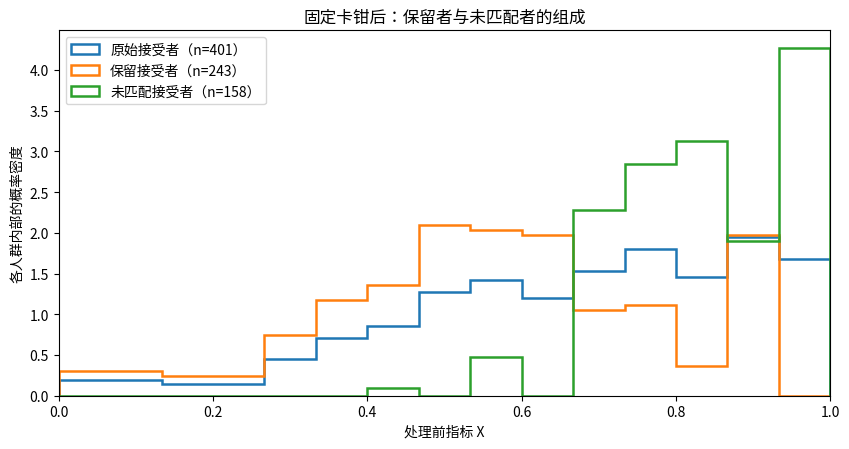

In [14]:
inspect_width = "0.03"
wa = weak_audits[inspect_width]
kept_ids = wa.loc[wa["matched"], "treated"].to_numpy(dtype=int)
lost_ids = wa.loc[~wa["matched"], "treated"].to_numpy(dtype=int)
print(f"阈值 {inspect_width}：保留 {len(kept_ids)} 位接受者，未匹配 {len(lost_ids)} 位。")
if len(lost_ids):
    lost_view = wa.loc[~wa["matched"], ["treated", "closest_available", "reason"]].copy()
    lost_view["X"] = weak_x[lost_view["treated"]]
    display(lost_view.sort_values("closest_available", ascending=False).head(8).round(4))
print(f"未用对照数：{int(weak_design_summary.loc[inspect_width, '未用对照'])}")

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for ids, label in [(np.flatnonzero(weak_t == 1), "原始接受者"),
                   (kept_ids, "保留接受者"), (lost_ids, "未匹配接受者")]:
    if len(ids):
        ax.hist(weak_x[ids], bins=np.linspace(0, 1, 16), density=True,
                histtype="step", linewidth=1.8, label=f"{label}（n={len(ids)}）")
ax.set(xlabel="处理前指标 X", ylabel="各人群内部的概率密度",
       title="固定卡钳后：保留者与未匹配者的组成", xlim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

### 3. 估计变化有两部分：换人，以及估计误差

模拟中可计算原始接受者和保留接受者各自的平均真实效应：

$$
\tau_{T,\mathrm{sample}}=\frac1{n_1}\sum_{i:T_i=1}\tau(X_i),
\qquad
\tau_{\mathcal S_T}=\frac1q\sum_{i\in\mathcal S_T}\tau(X_i).
$$

它们都是这一次样本里的真值，不是两个固定的总体常数。卡钳保留集合依赖估计评分、实际对照池和配对规则；不能未经说明把它等同于某个预先固定的总体子群。

下面对每个预设阈值报告估计、保留者真值和原始接受者真值，并核对：

$$
\widehat\tau_{\mathcal S_T}-\tau_{T,\mathrm{sample}}
=\bigl(\widehat\tau_{\mathcal S_T}-\tau_{\mathcal S_T}\bigr)
+\bigl(\tau_{\mathcal S_T}-\tau_{T,\mathrm{sample}}\bigr).
$$

左边的变化不能全算成“模型估计错了”，也不能全说成“卡钳让结果更准确”。阈值越小，保留人数越少；对照的剩余复用和结局噪声仍然存在。只报告一个效果值，会遗漏这些信息。

原始接受者的真实平均效应：3.02295


,保留人数,估计,保留者真值,相对保留者误差,人群变化
卡钳,,,,,
不限制,401,2.64569,3.02295,-0.37726,0.00000
0.20,363,2.65960,2.93393,-0.27433,-0.08902
0.08,294,2.57044,2.81498,-0.24454,-0.20797
0.03,243,2.53407,2.69965,-0.16559,-0.32330
0.01,153,2.49824,2.55591,-0.05767,-0.46704


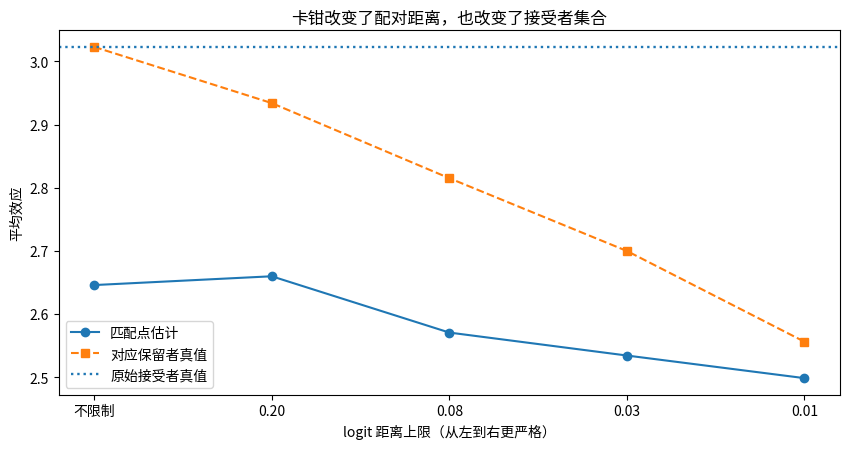

In [15]:
original_weak_att = weak_tau[weak_t == 1].mean()
weak_effect_rows = []
for name, _ in CALIPERS:
    pairs = weak_pairs[name]
    ids = np.unique(pairs["treated"])
    if not len(ids):
        weak_effect_rows.append({"卡钳": name, "保留人数": 0, "估计": np.nan,
                                "保留者真值": np.nan, "相对保留者误差": np.nan, "人群变化": np.nan})
        continue
    estimate, target = matched_att(weak_y, pairs), weak_tau[ids].mean()
    weak_effect_rows.append({"卡钳": name, "保留人数": len(ids), "估计": estimate,
                            "保留者真值": target, "相对保留者误差": estimate-target,
                            "人群变化": target-original_weak_att})
weak_effects = pd.DataFrame(weak_effect_rows).set_index("卡钳")
print(f"原始接受者的真实平均效应：{original_weak_att:.5f}")
display(weak_effects.round(5))
valid_rows = weak_effects["保留人数"] > 0
np.testing.assert_allclose(
    weak_effects.loc[valid_rows, "估计"]-original_weak_att,
    weak_effects.loc[valid_rows, "相对保留者误差"]+weak_effects.loc[valid_rows, "人群变化"], atol=1e-12,
)

fig, ax = plt.subplots(figsize=(8.6, 4.6))
pos = np.arange(len(weak_effects))
ax.plot(pos, weak_effects["估计"], marker="o", label="匹配点估计")
ax.plot(pos, weak_effects["保留者真值"], marker="s", linestyle="--", label="对应保留者真值")
ax.axhline(original_weak_att, linestyle=":", linewidth=1.7, label="原始接受者真值")
ax.set_xticks(pos, weak_effects.index)
ax.set(xlabel="logit 距离上限（从左到右更严格）", ylabel="平均效应",
       title="卡钳改变了配对距离，也改变了接受者集合")
ax.legend()
fig.tight_layout()
plt.show()

本次 0.03 卡钳保留了 401 位接受者中的 243 位，他们的平均真实效应从原始的 3.023 变成 2.700。匹配估计约为 2.534，比保留者真值还低约 0.166。因此，相对于原始接受者真值的下降，既有约 0.323 的人群变化，也有这一份数据中的估计误差。

## 重复模拟：不只比较一次结果

### 1. 每次都重新生成对象、拟合评分和匹配

回到三变量的主模拟。分别生成 600 人和 1,800 人的样本，每种规模重复 300 次。为了比较同一个目标，这里不设卡钳，保留所有接受者。

比较原始均值差、标准化 $X$ 匹配、其结果回归偏差校正，以及完整评分匹配。每次的结果模型和评分都从当前观察数据重新拟合。统计误差时使用前面数值积分得到的总体 ATT，不使用总体 ATE，也不拿每次略有变化的样本真值代替总体目标。

这里的重复模拟是研究算法表现：我们知道生成机制，所以能从总体重新抽取独立数据。它与对一份真实数据做 Bootstrap 不是同一个操作。

In [16]:
METHODS_REPEAT = ["原始均值差", "标准化X", "标准化X+校正", "完整评分"]
repeat_rows = []
rng_repeat = np.random.default_rng(SEED_REPEAT)
for n in SAMPLE_SIZES:
    for r in range(N_REPEATS):
        seed = int(rng_repeat.integers(0, 2**32-1))
        d, y, _ = make_observational_data(n, seed)
        z = d["T"].to_numpy()
        X = d[["X1", "X2", "X3"]].to_numpy()
        F = (X-X.mean(axis=0))/X.std(axis=0, ddof=1)
        px, _ = nearest_match(F, z)
        A = covariate_matrix(d, "rich")
        fit = fit_logistic(A, z)
        pe, _ = nearest_match(A @ fit.params, z)
        mu_hat = control_mean_predictions(d, y, "rich")
        corrected, _ = bias_corrected_att(y, px, mu_hat)
        values = [y[z == 1].mean()-y[z == 0].mean(), matched_att(y, px),
                  corrected, matched_att(y, pe)]
        for method, value in zip(METHODS_REPEAT, values):
            repeat_rows.append({"n": n, "repeat": r, "方法": method, "估计": value,
                                "误差": value-population_att})
    print(f"n={n}：完成 {N_REPEATS} 次独立重复。")
repeated = pd.DataFrame(repeat_rows)
assert len(repeated) == len(SAMPLE_SIZES)*N_REPEATS*len(METHODS_REPEAT)
assert np.isfinite(repeated["估计"]).all()

n=600：完成 300 次独立重复。


n=1800：完成 300 次独立重复。


### 2. 看平均偏差、波动和均方根误差

平均偏差反映估计是否长期偏向一边，经验标准差反映不同数据之间的波动；RMSE 同时包含二者。表中另外列出平均偏差的 Monte Carlo 标准误，避免把很小的模拟差异当成稳定结论。

偏差校正的结果模型在这套模拟里是正确设定的。它表现好，并不说明在任何数据中都能修好匹配；上一节已经把模型依赖单独保留下来。评分匹配把多维距离缩成一维，也不意味着每一对人的原始 $X$ 都相同。[1，第 15.2–15.4 节]

平均估计     平均偏差    经验标准差     RMSE  偏差的MC标准误
n    方法                                                   
600  原始均值差    4.23005  1.70362  0.25201  1.72209   0.01455
     标准化X     2.77294  0.24650  0.16675  0.29745   0.00963
     标准化X+校正  2.51321 -0.01323  0.13069  0.13114   0.00755
     完整评分     2.56040  0.03396  0.23209  0.23418   0.01340
1800 原始均值差    4.26997  1.74353  0.13824  1.74899   0.00798
     标准化X     2.65294  0.12650  0.08507  0.15236   0.00491
     标准化X+校正  2.53646  0.01002  0.07826  0.07877   0.00452
     完整评分     2.55501  0.02857  0.11045  0.11391   0.00638

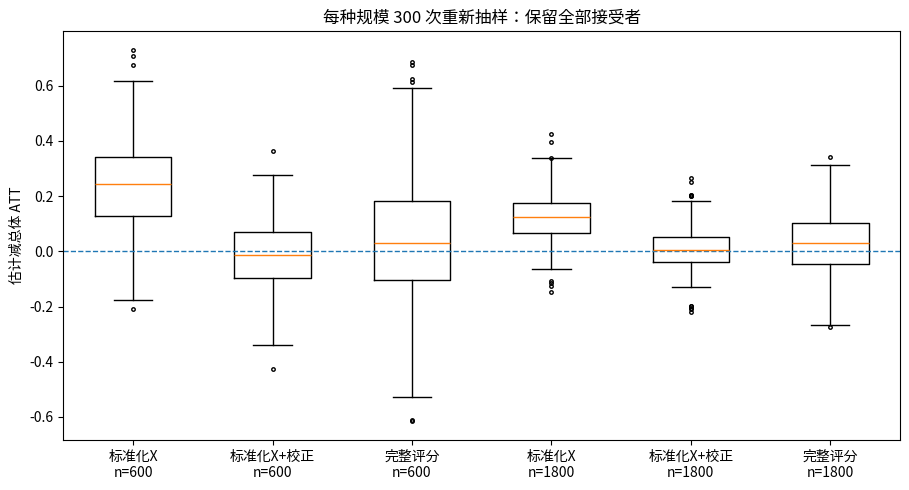

In [17]:
summary_rows = []
for n in SAMPLE_SIZES:
    for method in METHODS_REPEAT:
        result = repeated.loc[(repeated.n == n) & (repeated["方法"] == method), "估计"].to_numpy()
        error = result-population_att
        sd = result.std(ddof=1)
        summary_rows.append({"n": n, "方法": method, "平均估计": result.mean(),
                             "平均偏差": error.mean(), "经验标准差": sd,
                             "RMSE": np.sqrt(np.mean(error**2)),
                             "偏差的MC标准误": sd/np.sqrt(len(result))})
repeat_summary = pd.DataFrame(summary_rows).set_index(["n", "方法"])
display(repeat_summary.round(5))

fig, ax = plt.subplots(figsize=(9.2, 5.0))
box_data, labels = [], []
for n in SAMPLE_SIZES:
    for method in METHODS_REPEAT[1:]:
        box_data.append(repeated.loc[(repeated.n == n) & (repeated["方法"] == method), "误差"].to_numpy())
        labels.append(f"{method}\nn={n}")
ax.boxplot(box_data, tick_labels=labels, showfliers=True, widths=0.55,
           flierprops={"markersize": 2.5})
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(ylabel="估计减总体 ATT", title=f"每种规模 {N_REPEATS} 次重新抽样：保留全部接受者")
fig.tight_layout()
plt.show()

在这组重复结果中，标准化 $X$ 匹配的平均偏差从约 0.247 降到 0.127；匹配更细了，但剩余差异仍不能忽略。偏差校正后，两种规模的平均偏差分别约为 −0.013 和 0.010。完整评分匹配的波动也随样本增加而减小，但有限样本的平均偏差并未严格等于零。

这些数字描述的是本例的重复表现，不是从一次结果推断出的“显著性”。下一节再单独看为什么复用对照会影响误差范围。

## 不确定性：同一个对照不是多位独立受试者

### 1. 先算一个能完全核对的方差

原书第 15.2 节指出，放回匹配带来的复用会引入依赖。下面不构造通用置信区间，只做一个已知噪声的计算实验：固定 $X,T$ 和配对，每位原始对象的结局噪声相互独立，方差都为 $\sigma^2$。

一对一匹配下，平均噪声差为：

$$
R=\frac1q\left(\sum_{i\in\mathcal S_T}\varepsilon_i-
\sum_{j:T_j=0}K_j\varepsilon_j\right).
$$

因此，在固定配对的条件下：

$$
\operatorname{Var}(R\mid X,T,\text{配对})
=\frac{\sigma^2}{q^2}\left(q+\sum_jK_j^2\right).
$$

这里出现的是 $K_j^2$，不是 $K_j$。同一对照的噪声被用了 12 次，它是 $12\varepsilon_j$，而不是 12 个独立噪声之和。若错把全部配对视为相互独立，会算成 $2\sigma^2/q$。

这个方差是本篇在额外的独立、同方差噪声设定下推导的，用来隔离复用问题；不包括一般研究中的匹配偏差、估计评分、样本选择及效应异质性等全部不确定性。

,方差
正确的条件方差,0.49000
误当独立配对的方差,0.10000
重复生成噪声得到的方差,0.49395


3 位对照的使用次数： [12, 4, 4]


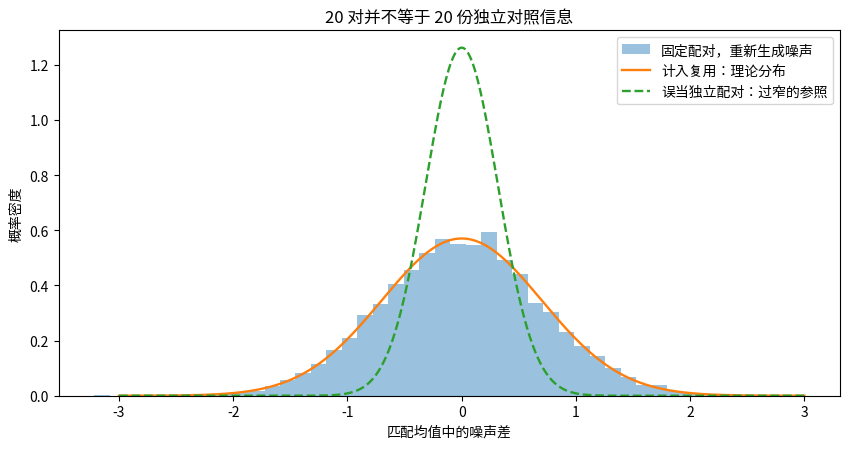

In [18]:
# 20 位接受者分别靠近 3 位对照，得到使用次数 12、4、4。
noise_x = np.r_[0.10+np.arange(12)*0.001, 0.60+np.arange(4)*0.001,
                0.90+np.arange(4)*0.001, 0.11, 0.61, 0.91]
noise_t = np.r_[np.ones(20, dtype=int), np.zeros(3, dtype=int)]
noise_pairs, _ = nearest_match(noise_x, noise_t)
noise_w1, noise_w0 = matching_weights(noise_pairs, len(noise_t))
q = noise_w1.sum()
sigma = 1.0
actual_variance = sigma**2*(q+np.dot(noise_w0, noise_w0))/q**2
independent_pair_variance = 2*sigma**2/q

rng_noise = np.random.default_rng(SEED_NOISE)
epsilon = rng_noise.normal(0, sigma, (N_NOISE_REPEATS, len(noise_t)))
noise_estimates = epsilon @ (noise_w1-noise_w0)/q
empirical_variance = noise_estimates.var(ddof=1)
display(pd.Series({"正确的条件方差": actual_variance,
                   "误当独立配对的方差": independent_pair_variance,
                   "重复生成噪声得到的方差": empirical_variance}, name="方差").to_frame().round(5))
print("3 位对照的使用次数：", noise_w0[noise_t == 0].astype(int).tolist())
np.testing.assert_allclose(actual_variance, 0.49, atol=1e-12)
np.testing.assert_allclose(independent_pair_variance, 0.10, atol=1e-12)

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.hist(noise_estimates, bins=45, density=True, alpha=0.45, label="固定配对，重新生成噪声")
grid = np.linspace(-3, 3, 500)
for variance, label, style in [(actual_variance, "计入复用：理论分布", "-"),
                              (independent_pair_variance, "误当独立配对：过窄的参照", "--")]:
    density = np.exp(-grid**2/(2*variance))/np.sqrt(2*np.pi*variance)
    ax.plot(grid, density, linestyle=style, linewidth=1.7, label=label)
ax.set(xlabel="匹配均值中的噪声差", ylabel="概率密度",
       title="20 对并不等于 20 份独立对照信息")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 为什么不照搬上一篇的 Bootstrap？

上一份对 IPW 重抽整行数据、重新拟合评分。最近邻匹配中，一个样本稍有变化，谁是谁的最近邻就可能跳变。Ding 第 15.3.1 节明确讨论了普通重抽样 Bootstrap 对匹配估计方差可能失效的问题，不能把“每次都重新匹配”当作有效性的保证。[1，第 15.3.1 节]

原书随后给出偏差校正估计的线性展开与方差讨论。本篇核对了其中 ATT 的点估计恒等式，没有把该方差表达式直接移用到所有估计评分、卡钳删人和贪心无放回的流程。前面的经验标准差来自重新生成数据，上一小节则是固定设计的已知噪声实验，两者都不是从一份真实数据得到的通用标准误。

同样，观察性研究里“配成了对”不等于真的做过随机分配。原书第 15.1 节先在精确匹配的理想条件下讨论与配对试验的联系，随后指出非精确匹配下这套随机化论证不能直接沿用。这里不对近邻配对随意翻转处理标签来报告精确 p 值。[1，第 15.1 节]

## 练习

### 1. 一对三是否一定比一对一更好？

保持主案例的完整 logit 评分不变，分别做一对一、一对三和一对五的有放回匹配，不设卡钳。所有接受者都保留，因此仍比较同一个目标。

先判断：新增的第 3、5 个邻居会不会离接受者更远？对照的权重是被选次数 $K_j$，还是 $K_j/M$？对照变多后，点估计是否就一定更接近真值？

下面同时列出匹配距离、不同对照人数、ESS 与效应。扩展为一对多来自原书第 15.2、15.4 节；这些具体规模和输出表是本篇练习设置。

In [19]:
ratio_rows = []
for M in (1, 3, 5):
    pairs_M, audit_M = nearest_match(logits["rich"], t, ratio=M, replace=True)
    wt, wc = matching_weights(pairs_M, len(t))
    # 先对每位接受者的 M 位对照求平均，再对接受者等权平均。
    with_y = pairs_M.assign(control_y=outcome[pairs_M["control"].to_numpy()])
    counterfactual_mean = with_y.groupby("treated", sort=True)["control_y"].mean()
    ids = counterfactual_mean.index.to_numpy(dtype=int)
    direct = np.mean(outcome[ids]-counterfactual_mean.to_numpy())
    np.testing.assert_allclose(direct, matched_att(outcome, pairs_M), atol=1e-11)
    np.testing.assert_allclose(wc.sum(), wt.sum(), atol=1e-10)
    assert int(wt.sum()) == int(t.sum())
    ratio_rows.append({"M": M, "接受者人数": len(ids), "不同对照": int((wc > 0).sum()),
                       "对照ESS": effective_sample_size(wc),
                       "平均配对距离": pairs_M["distance"].mean(),
                       "最远配对距离": pairs_M["distance"].max(),
                       "估计": direct, "减本次接受者真值": direct-sample_att})
display(pd.DataFrame(ratio_rows).set_index("M").round(5))
print("三种比例的对照总权重都等于原始接受者人数，而不是配对长表的行数。")

,接受者人数,不同对照,对照ESS,平均配对距离,最远配对距离,估计,减本次接受者真值
M,,,,,,,
1,1435,660,309.79765,0.00660,0.24774,2.66696,0.13124
3,1435,1173,432.76182,0.01430,0.87850,2.65528,0.11956
5,1435,1354,468.36760,0.02032,1.00443,2.63082,0.09510


三种比例的对照总权重都等于原始接受者人数，而不是配对长表的行数。


本次从一对一增至一对五，对照 ESS 从约 310 增至 468，但最大 logit 配对距离也从 0.248 增至 1.004。点估计在这一次恰好更接近真值，不能据此推出 $M$ 越大越好；新增对照既带来信息，也可能带来更远的比较。

### 2. 无放回匹配时，顺序会改变结果吗？

另给两位接受者的匹配坐标 0.40、0.52，两位对照的坐标 0.30、0.45，卡钳为 0.12。

先匹配 0.40 时，会选最近的 0.45；0.52 随后只剩 0.30，超出卡钳。若先匹配 0.52，它选 0.45，0.40 还能选 0.30，两人都能留下。这里用同一坐标尺度上的绝对距离，与主案例的评分拟合无关。

下面交换顺序，再把两种完整的一对一安排全部枚举。枚举只用于核对这个小例子，不把顺序贪心程序称为全局最优算法。

In [20]:
order_x = np.array([0.40, 0.52, 0.30, 0.45])
order_t = np.array([1, 1, 0, 0])
order_results = []
for label, sequence in [("先0.40", [0, 1]), ("先0.52", [1, 0])]:
    pairs_order, audit_order = nearest_match(order_x, order_t, replace=False,
                                            caliper=0.12, order=sequence)
    order_results.append({"顺序": label, "保留接受者": int(audit_order["matched"].sum()),
                          "匹配总距离": pairs_order["distance"].sum(),
                          "配对": [(float(order_x[i]), float(order_x[j]))
                                  for i, j in zip(pairs_order.treated, pairs_order.control)]})
display(pd.DataFrame(order_results).set_index("顺序"))

all_arrangements = []
for arrangement in permutations([2, 3]):
    distances = np.abs(order_x[:2]-order_x[list(arrangement)])
    all_arrangements.append({"对照行位置顺序": arrangement,
                             "全部满足卡钳": bool(np.all(distances <= 0.12)),
                             "总距离": distances.sum()})
display(pd.DataFrame(all_arrangements).round(4))
assert [r["保留接受者"] for r in order_results] == [1, 2]
assert sum(row["全部满足卡钳"] for row in all_arrangements) == 1

# 有放回时，交换访问顺序不会改变每位接受者挑选的最近对照。
p_forward, _ = nearest_match(order_x, order_t, replace=True, order=[0, 1])
p_reverse, _ = nearest_match(order_x, order_t, replace=True, order=[1, 0])
pd.testing.assert_frame_equal(p_forward.sort_values("treated").reset_index(drop=True),
                              p_reverse.sort_values("treated").reset_index(drop=True))
print("核对通过：无放回贪心受顺序影响；本例有放回的逐人配对不受访问顺序影响。")

,保留接受者,匹配总距离,配对
顺序,,,
先0.40,1,0.05,"[(0.4, 0.45)]"
先0.52,2,0.17,"[(0.52, 0.45), (0.4, 0.3)]"


,对照行位置顺序,全部满足卡钳,总距离
0,"(2, 3)",True,0.17
1,"(3, 2)",False,0.27


核对通过：无放回贪心受顺序影响；本例有放回的逐人配对不受访问顺序影响。


## 小结

匹配先为接受者寻找可比对照，再平均结局差。只为接受者补未处理结局时，目标是 ATT；不能因为样本里有两组，就把结果称为全体 ATE。

完整的匹配结果至少应保留配对索引、距离、接受者的去留、不同对照人数和复用权重。评分接近之后，还要检查原始变量及相关非线性项的平衡。复用对照时，去重后等权平均会改变估计；把重复配对当成独立数据又会误读不确定性。

卡钳排除难匹配者可能改变目标人群，结果回归可以校正部分基线差异，但也有模型依赖。下一篇把结果回归与倾向评分放在同一个估计式中，讨论双重稳健估计。

## 参考资料与本篇改写范围

[1] Peng Ding. *A First Course in Causal Inference*. 上传文件《因果推断.pdf》，arXiv:2305.18793v2，2023-10-03。第 13.1 节用于 ATT 的定义与一侧识别；第 15.1–15.2 节用于精确与近邻匹配、距离、有无放回、一对多及难匹配者的排除；第 15.3.1 节用于偏差校正及 Bootstrap 的限制；第 15.4 节用于 ATT 匹配式、校正项与命题 15.3 的残差表达。另参考第 11.3、15.5.3 节的平衡检查。主要正文页 181–182、203–210，对应该附件 PDF 页 207–208、229–236。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传文件《CausalML_book_2022.pdf》，扉页版本 0.1.2，2026-05-03。第 5.5 节用 ATET 表示已接受处理者的平均效应，并给出条件化识别式；正文页 145–146，对应 PDF 页 155–156。这里只对照该定义，不将本篇的近邻实现或卡钳规则归于第二本书。

[3] statsmodels 官方二项 GLM 接口文档。实现时显式加入截距与 `Binomial` 分布，用于估计倾向评分；结果回归的最小二乘由 NumPy 实现。接口说明：`https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html`。实际执行版本见开头输出。

计算范围说明：本篇没有复现第 15.5 节 LaLonde 的实证结果。观察数据与潜在真值分开保存，匹配函数不读取结局；数值积分、卡钳的样本去向表、SMD 固定分母、使用次数权重、条件噪声方差和顺序枚举属于围绕原书方法新增的教学计算，不冒充书中的原始定理或实验。原书的 ATE 双向匹配及匹配方差的一般实现不在本篇范围内；偏差校正只核对 ATT 点估计与其代数表达，没有将其解释成所有场景都适用的双重稳健保证。